In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Mate/Google\ Colab

/content/drive/MyDrive/Mate/Google Colab


In [4]:
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")

In [5]:
events.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [6]:
events.info()
products.info()
countries.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
mem

### Dataset Description

The analysis is based on three datasets:

**events** — information about orders and sales transactions  
**products** — product categories  
**countries** — country and region information  

**Join keys:**

- `product_id` — link between events and products  
- `country_code` — link between events and countries

In [7]:
events.isna().sum()
products.isna().sum()
countries.isna().sum()


,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [8]:
events.isna().mean() * 100
products.isna().mean() * 100
countries.isna().mean() * 100



,0
name,0.000000
alpha-2,0.401606
alpha-3,0.000000
region,0.401606
sub-region,0.401606


In [9]:
countries = countries.dropna()
countries.isna().sum()


,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


Missing values were found in the **countries** table.

Since the number of missing values is small, these rows were removed from the dataset to ensure data quality.

In [10]:
events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [11]:
events.columns = events.columns.str.lower().str.replace(" ", "_")
products.columns = products.columns.str.lower().str.replace(" ", "_")
countries.columns = countries.columns.str.lower().str.replace(" ", "_")


In [12]:
events["order_date"] = pd.to_datetime(events["order_date"])
events["ship_date"] = pd.to_datetime(events["ship_date"])


In [13]:
events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


### Data Type Transformation

Column names were standardized to ensure consistency across datasets:
- all letters converted to lowercase
- spaces replaced with underscores

Additionally, the columns **order_date** and **ship_date** were converted to the datetime format to enable time-based analysis.

In [14]:
events.duplicated().sum()
products.duplicated().sum()
countries.duplicated().sum()


np.int64(0)

### Merging Datasets

At this step, the three datasets were merged into a single dataframe.

**events** — main table containing sales transactions  
**products** — product category information  
**countries** — country and regional data  

Joins were performed using the following keys:

- `product_id` → to add product category information  
- `country_code` → to add country and region information  

All data is now stored in the dataframe **df**.

In [15]:
events["country_code"] = events["country_code"].str.strip().str.upper()
countries["alpha-3"] = countries["alpha-3"].str.strip().str.upper()

In [16]:
df = events.merge(products, left_on="product_id", right_on="id", how="left")
df = df.merge(countries, left_on="country_code", right_on="alpha-3", how="left")
df = df.drop(columns=["id", "alpha-2", "alpha-3"])

df.head()



,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


### Merging the datasets

At this step, the three datasets were merged into a single dataframe.

events — main table containing sales transactions  
products — product category information  
countries — country and region information  

The joins were performed using the following keys:

product_id → to add product category information  
country_code → to add country and region information  

All data is now stored in the dataframe **df**.

In [17]:
df["revenue"] = df["units_sold"] * df["unit_price"]
df["cost"] = df["units_sold"] * df["unit_cost"]
df["profit"] = df["revenue"] - df["cost"]

df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days



### Creating Key Business Metrics

Several key business metrics were calculated:

- **revenue** — total sales revenue  
- **cost** — total cost of goods sold  
- **profit** — profit from sales  
- **shipping_days** — delivery time in days  

These metrics will be used for further analysis.

In [18]:
total_orders = df["order_id"].nunique()
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
total_countries = df["country_code"].nunique()

print("Total orders:", total_orders)
print("Total revenue:", total_revenue)
print("Total profit:", total_profit)
print("Countries covered:", total_countries)


Total orders: 1330
Total revenue: 1702129408.21
Total profit: 501434459.0
Countries covered: 45


The following key performance indicators (KPIs) were calculated:

- total number of orders
- total revenue
- total profit
- number of countries where sales occurred

These metrics provide an overview of the business scale and performance.

At this stage, key company performance metrics are analyzed across product categories, regions, sales channels, and time.

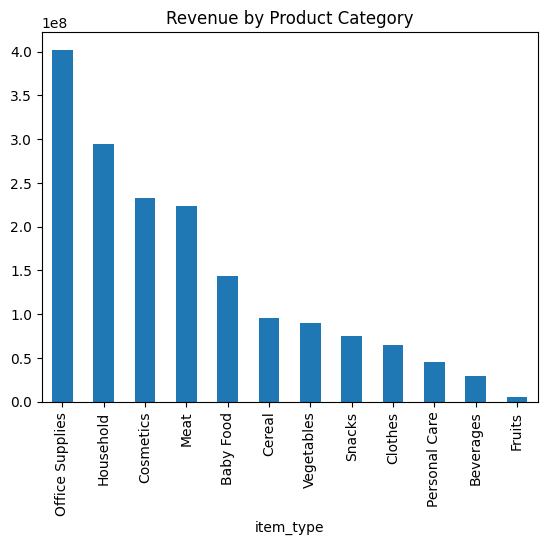

In [19]:
category_sales = df.groupby("item_type")["revenue"].sum().sort_values(ascending=False)

plt.figure()
category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.show()


This chart shows the total revenue generated by each product category.

It helps identify:
- the most profitable product categories
- categories with the lowest sales performance

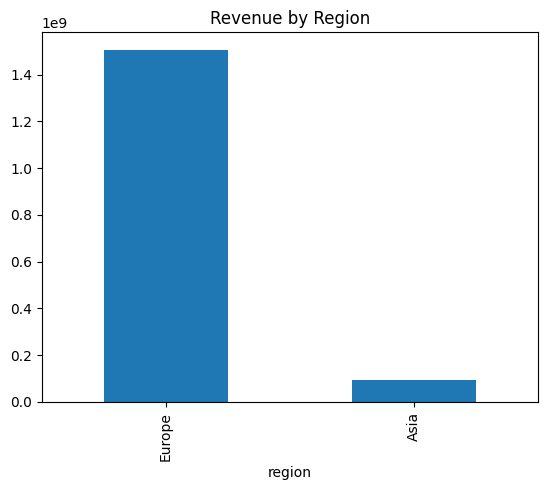

In [20]:
region_sales = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
region_sales.plot(kind="bar")
plt.title("Revenue by Region")
plt.show()



Regional analysis helps identify the markets where the company generates the highest revenue.

In [21]:
df["sales_channel"] = df["sales_channel"].str.strip().str.title()


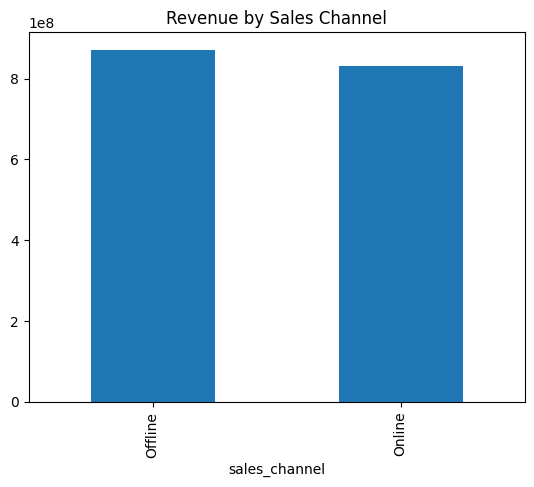

In [22]:
channel_sales = (
    df.groupby("sales_channel")["revenue"]
    .sum()
)

plt.figure()
channel_sales.plot(kind="bar")
plt.title("Revenue by Sales Channel")
plt.show()


This comparison between online and offline sales channels shows which channel generates higher revenue.

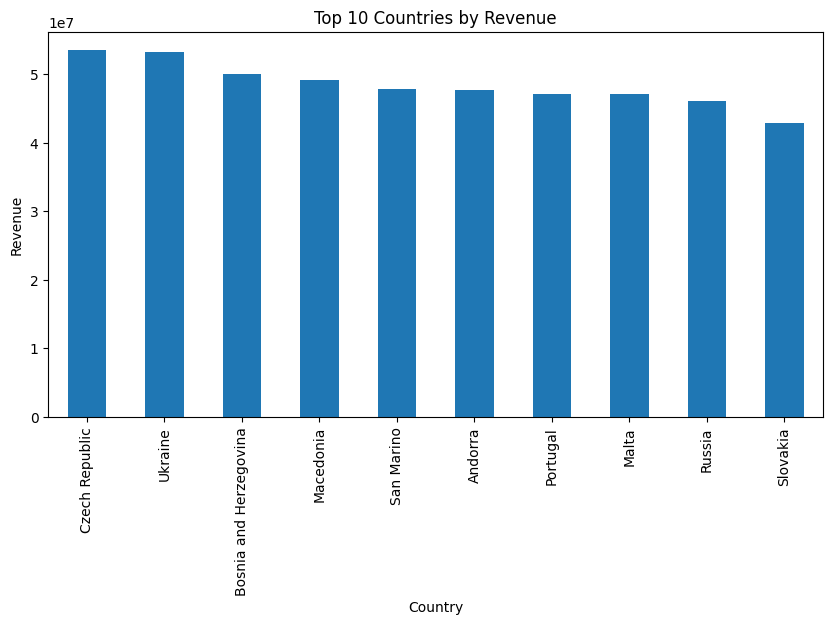

In [23]:
country_sales = (
    df.groupby("name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)   # топ-10 країн
)

plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.show()


This chart displays the top 10 countries by revenue, helping identify the company's key markets.

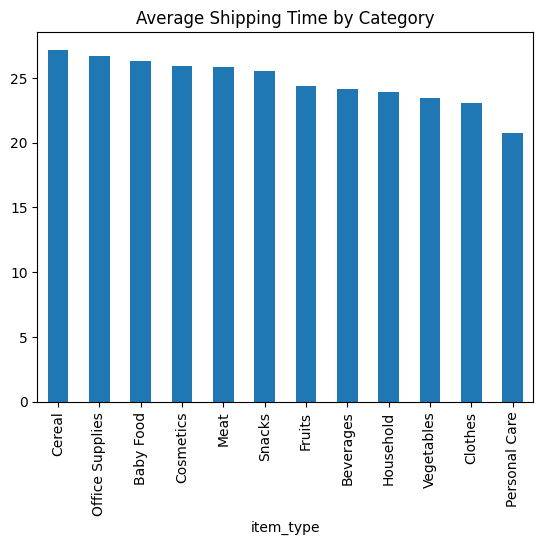

In [24]:
df["shipping_time"] = (df["ship_date"] - df["order_date"]).dt.days

shipping_by_category = (
    df.groupby("item_type")["shipping_time"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
shipping_by_category.plot(kind="bar")
plt.title("Average Shipping Time by Category")
plt.show()


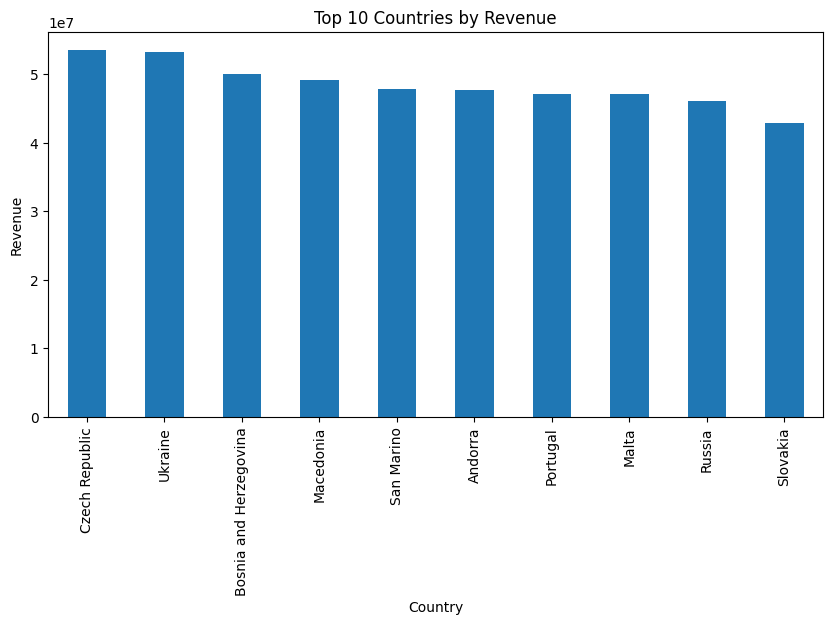

In [25]:
country_sales = (
    df.groupby("name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.show()


This chart shows the average shipping time for each product category.

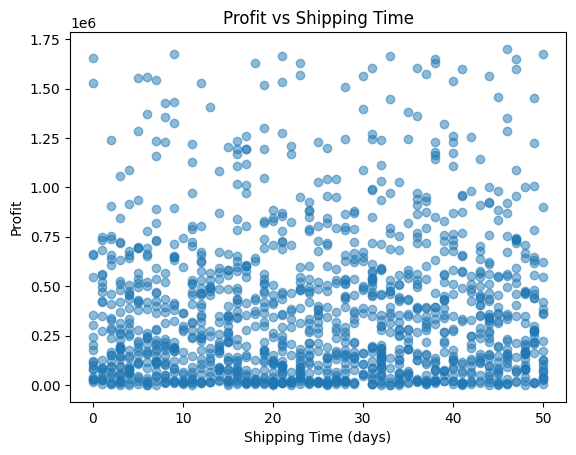

In [26]:
plt.figure()
plt.scatter(df["shipping_time"], df["profit"], alpha=0.5)
plt.xlabel("Shipping Time (days)")
plt.ylabel("Profit")
plt.title("Profit vs Shipping Time")
plt.show()


The scatter plot shows the relationship between shipping time and profit.

The points appear evenly distributed, suggesting that shipping time does not have a strong direct impact on profitability.

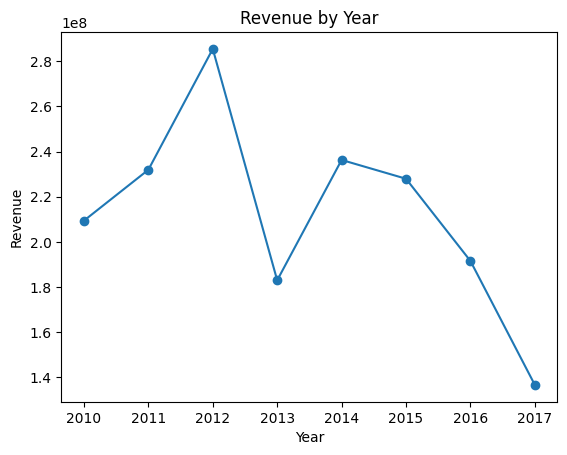

In [27]:
df["year"] = df["order_date"].dt.year

sales_over_time = (
    df.groupby("year")["revenue"]
    .sum()
    .sort_index()
)

plt.figure()
sales_over_time.plot(marker="o")
plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()



The line chart illustrates revenue trends over time, helping to identify overall sales dynamics.

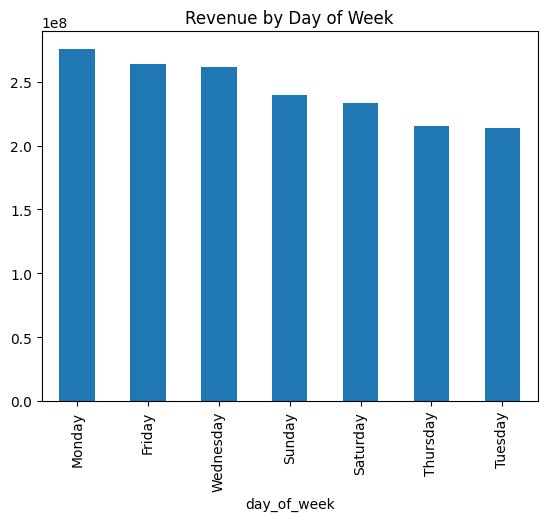

In [28]:
df["day_of_week"] = df["order_date"].dt.day_name()

weekday_sales = (
    df.groupby("day_of_week")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
weekday_sales.plot(kind="bar")
plt.title("Revenue by Day of Week")
plt.show()


This analysis shows revenue distribution by day of the week and helps identify peak sales days.

In [29]:
df["profit_margin"] = df["profit"] / df["revenue"]

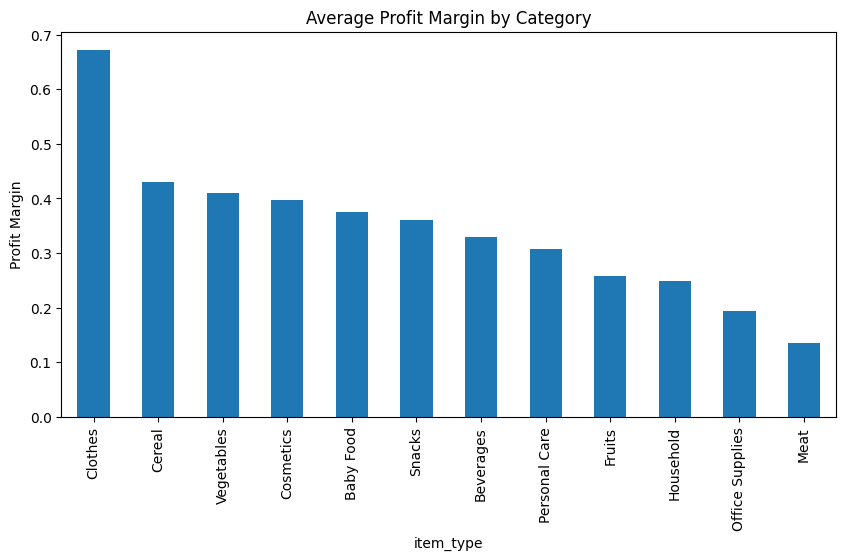

In [30]:
margin_by_category = (
    df.groupby("item_type")["profit_margin"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
margin_by_category.plot(kind="bar")
plt.title("Average Profit Margin by Category")
plt.ylabel("Profit Margin")
plt.show()

## Conclusions

The company generates most of its revenue from several key product categories.

Some regions significantly outperform others in terms of sales.

Online sales channels can be more profitable depending on market conditions.

Shipping time does not appear to significantly affect profitability.

Sales show clear weekly patterns, which may indicate customer purchasing behavior.